## Configuración del Entorno

Google Drive fue montado para acceder al dataset, modelos entrenados y archivos del proyecto almacenados en la nube.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Se instaló la librería Ultralytics para utilizar el framework de detección de objetos YOLOv8. Además, se importaron librerías adicionales de Python como OpenCV y utilidades del sistema para apoyar el procesamiento de imágenes, manejo de archivos y generación de visual analytics.

In [ ]:
%%capture
!pip install ultralytics

In [ ]:
import os
import cv2
import warnings
import shutil
warnings.filterwarnings("ignore")

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Carga del Dataset y Modelo Preentrenado

Se definió la ruta principal del proyecto dentro de Google Drive para acceder al dataset y a los modelos previamente entrenados.

Posteriormente, se verificó correctamente la existencia del archivo `data.yaml`, el cual contiene la configuración del dataset en formato YOLO, así como el modelo previamente entrenado `best_futbol_equipo_v2.pt`.

In [ ]:
project_path = "/content/drive/MyDrive/IA 2"

data_yaml = os.path.join(project_path, "Data", "data.yaml")
previous_model = os.path.join(project_path, "best_futbol_equipo_v2.pt")

print("Carpeta de proyecto encontrada:", os.path.exists(project_path))
print("Se encontró el dataset de datos YAML:", os.path.exists(data_yaml))
print("Modelo anterior encontrado:", os.path.exists(previous_model))

Carpeta de proyecto encontrada: True
Se encontró el dataset de datos YAML: True
Modelo anterior encontrado: True



El modelo preentrenado fue cargado utilizando la librería Ultralytics YOLOv8 con el objetivo de aplicar transferencia de aprendizaje y continuar el entrenamiento utilizando un dataset más amplio y actualizado.

Esta estrategia permitió aprovechar características previamente aprendidas por el modelo y reducir el tiempo total de entrenamiento.

In [ ]:
model = YOLO(previous_model)

print("El modelo anterior se cargó correctamente.")

El modelo anterior se cargó correctamente.


## Entrenamiento del Modelo

El entrenamiento del modelo se realizó utilizando YOLOv8 junto con transferencia de aprendizaje a partir de un modelo previamente entrenado.

Se utilizaron los hiperparámetros obtenidos previamente durante la etapa de optimización, con el objetivo de mejorar el desempeño general del detector sobre el dataset actualizado.

Los principales hiperparámetros utilizados fueron:

- Epochs: 50
- Image size: 640 × 640
- Batch size: 8
- Learning rate inicial: 0.001
- Early stopping con paciencia de 10 epochs


In [ ]:
results = model.train(
    data=data_yaml,
    epochs=50,
    imgsz=640,
    batch=8,
    lr0=0.001,
    patience=10,
    name="modelo_futbol_v3_optimizado",
    seed=42,
    device=0
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/IA 2/Data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/IA 2/best_futbol_equipo_v2.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=modelo_futbol_v3_optimizado, nbs=64, nms=False, op

Durante el entrenamiento se aplicó Early Stopping, deteniendo automáticamente el proceso cuando no se observaron mejoras significativas durante 10 epochs consecutivos. El mejor desempeño del modelo fue obtenido alrededor de la época 22, guardándose automáticamente el archivo `best.pt`.

El entrenamiento completo finalizó después de 32 epochs, logrando un modelo funcional para la detección de jugadores y balón en secuencias de video aéreo.

## Resultados del Entrenamiento

Una vez finalizado el entrenamiento, el modelo fue evaluado utilizando el conjunto de validación.

Los resultados mostraron un mejor desempeño en la detección de jugadores en comparación con el balón, lo cual era esperado debido a que el balón representa un objeto significativamente más pequeño y difícil de detectar dentro de las tomas aéreas.

Las métricas principales obtenidas fueron las siguientes:

| Clase | Precision | Recall | mAP50 |
|---|---|---|---|
| Player (P) | 0.832 | 0.875 | 0.866 |
| Ball (B) | 0.629 | 0.262 | 0.239 |

El modelo logró detectar correctamente la mayoría de los jugadores presentes en la cancha, obteniendo métricas relativamente altas para esta clase.

Sin embargo, la detección del balón continuó representando el principal reto del proyecto debido a factores como:
- tamaño reducido del balón dentro de la imagen,
- desenfoque por movimiento,
- baja cantidad de píxeles visibles,
- y similitud visual con otros elementos del entorno.

A pesar de estas limitaciones, el modelo fue capaz de detectar el balón en múltiples frames del video, permitiendo continuar con la generación de visual analytics.

## Guardado y Carga del Modelo Entrenado

Una vez finalizado el entrenamiento, el mejor modelo generado (`best.pt`) fue guardado manualmente en Google Drive para evitar la pérdida de información en caso de reinicio del entorno de Google Colab.


In [ ]:
source_model = "/content/runs/detect/modelo_futbol_v3_optimizado/weights/best.pt"
destination_model = "/content/drive/MyDrive/IA 2/best_modelo_futbol_v3_optimizado.pt"

shutil.copy(source_model, destination_model)

print("Modelo guardado en Drive:", os.path.exists(destination_model))

Modelo guardado en Drive: True


Posteriormente, el modelo guardado fue cargado nuevamente utilizando la librería YOLOv8 para continuar con la etapa de evaluación e inferencia.

Este procedimiento permitió reutilizar el modelo entrenado sin necesidad de repetir nuevamente todo el proceso de entrenamiento, optimizando así el flujo de trabajo y el uso de recursos computacionales.

In [ ]:
best_model_path = "/content/runs/detect/modelo_futbol_v3_optimizado/weights/best.pt"

best_model = YOLO(best_model_path)

print("Best model loaded successfully.")

Best model loaded successfully.


In [ ]:
metrics = best_model.val(
    data=data_yaml,
    split="test"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.2 ms, read: 0.1±0.0 MB/s, size: 64.1 KB)
val: Scanning /content/drive/MyDrive/IA 2/Data/test/labels... 42 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 42/42 1.0it/s 41.9s
val: New cache created: /content/drive/MyDrive/IA 2/Data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4s/it 4.2s
                   all         42        707      0.764      0.658      0.651      0.381
                    AC         42        112      0.922      0.759       0.81      0.708
                     B         42         43      0.637      0.302      0.254     0.0779
                    MC         42         48      0.674      0.708      0.693      0.273
                     P         42        504      0.822      0.86

## Evaluación del Modelo

Después de cargar el mejor modelo entrenado, se realizó la evaluación utilizando el conjunto de prueba definido dentro del dataset.

La validación permitió medir el desempeño del detector utilizando métricas estándar de object detection como Precision, Recall y mAP50.

Los resultados obtenidos fueron los siguientes:

| Clase | Precision | Recall | mAP50 |
|---|---|---|---|
| Player (P) | 0.822 | 0.861 | 0.847 |
| Ball (B) | 0.637 | 0.302 | 0.254 |

Los resultados muestran que el modelo logró un desempeño sólido en la detección de jugadores, obteniendo altos valores de precision y recall.

Por otro lado, la detección del balón continuó siendo el mayor desafío del proyecto debido a su pequeño tamaño dentro de las imágenes aéreas y a la dificultad de distinguirlo correctamente en todos los frames del video.

A pesar de estas limitaciones, el modelo fue capaz de detectar el balón en distintas secuencias, permitiendo continuar con la generación de visual analytics y análisis espacial dentro de la cancha.

## Inferencia Segmentada con SAHI

Con el objetivo de mejorar la detección de objetos pequeños, especialmente el balón, se implementó una estrategia de inferencia segmentada utilizando la librería SAHI (Slicing Aided Hyper Inference).

Esta técnica divide cada frame en múltiples regiones más pequeñas antes de aplicar el detector YOLOv8, permitiendo que objetos pequeños ocupen una mayor proporción de la imagen analizada y mejorando así su probabilidad de detección.

El modelo previamente entrenado fue cargado dentro del framework SAHI utilizando aceleración por GPU para mantener tiempos de inferencia razonables.

In [ ]:
%%capture
!pip install sahi

In [ ]:
import glob
import numpy as np
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from google.colab.patches import cv2_imshow

In [ ]:
model_path = "/content/drive/MyDrive/IA 2/best_modelo_futbol_v3_optimizado.pt"

sahi_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=model_path,
    confidence_threshold=0.15,
    device="cuda:0"
)

print("SAHI model loaded successfully.")

SAHI model loaded successfully.


## Extracción de Frames del Video

Para facilitar las pruebas y evaluación del modelo, se extrajeron distintos frames representativos del video original de fútbol.

Se seleccionaron frames distribuidos a lo largo de toda la secuencia con el objetivo de evaluar el comportamiento del detector bajo diferentes posiciones de jugadores y balón dentro de la cancha.

Cada frame extraído fue almacenado temporalmente para posteriormente aplicar inferencia segmentada y generar visual analytics.

In [ ]:
video_path = "/content/drive/MyDrive/IA 2/futbol.mp4"
frames_dir = "/content/test_frames"

os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_ids = [100, 400, 800, 1200, 1600, 2000, 2400, 2800, 3200, 3600]

for frame_id in frame_ids:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()

    if ret:
        frame_path = os.path.join(frames_dir, f"frame_{frame_id}.jpg")
        cv2.imwrite(frame_path, frame)

cap.release()

print("Frames guardados correctamente.")

Frames guardados correctamente.


## Filtrado de Detecciones por Clase

Después de aplicar inferencia segmentada con SAHI, se observó un incremento en la sensibilidad del detector, especialmente en la detección del balón. Sin embargo, también aumentó el número de falsos positivos en la clase de jugadores.

Para solucionar este problema, se implementó un sistema de filtrado por clase utilizando diferentes umbrales de confianza para cada objeto detectado.

Se utilizó un umbral de confianza más alto para los jugadores y un umbral más bajo para el balón, debido a que el balón representa un objeto considerablemente más pequeño y difícil de detectar en las imágenes aéreas.

Esta estrategia permitió mantener una mejor detección del balón sin incrementar excesivamente las detecciones incorrectas de jugadores.

In [ ]:
frame_path = "/content/test_frames/frame_1600.jpg"

result = get_sliced_prediction(
    frame_path,
    sahi_model,
    slice_height=320,
    slice_width=320,
    overlap_height_ratio=0.25,
    overlap_width_ratio=0.25
)

filtered_predictions = []

for pred in result.object_prediction_list:

    class_name = pred.category.name
    score = pred.score.value

    # Players con confianza alta
    if class_name == "P" and score >= 0.40:
        filtered_predictions.append(pred)

    # Ball con confianza baja
    elif class_name == "B" and score >= 0.15:
        filtered_predictions.append(pred)

print("Filtered detections:", len(filtered_predictions))

Performing prediction on 15 slices.
Filtered detections: 12


## Configuración de Umbrales para Detecciones y Regiones

Después de la primera visualización, se amplió el filtrado de detecciones para incluir no solo jugadores y balón, sino también las regiones relevantes de la cancha.

Se utilizaron umbrales de confianza específicos para cada clase:

- `P`: jugadores
- `B`: balón
- `AC`: área chica
- `MC`: medio campo

Esta configuración permitió conservar las detecciones útiles para el análisis deportivo y eliminar detecciones con baja confianza. Además, las clases `AC` y `MC` fueron utilizadas para generar regiones dinámicas de la cancha, evitando depender completamente de coordenadas manuales.

In [ ]:
player_conf = 0.30
ball_conf = 0.10
ac_conf = 0.35
mc_conf = 0.25

max_balls = 1
max_ac = 2
max_mc = 1

def filter_sahi_predictions_all(result):
    detections_by_class = {
        "P": [],
        "B": [],
        "AC": [],
        "MC": []
    }

    for pred in result.object_prediction_list:
        class_name = pred.category.name
        score = pred.score.value
        bbox = pred.bbox

        width = bbox.maxx - bbox.minx
        height = bbox.maxy - bbox.miny

        if class_name == "P" and score >= player_conf:
             # Filtrar detecciones demasiado pequeñas
             if width >= 8 and height >= 12:
                detections_by_class["P"].append(pred)

        elif class_name == "B" and score >= ball_conf:
            if width >= 4 and height >= 4:
                detections_by_class["B"].append(pred)

        elif class_name == "AC" and score >= ac_conf:
            detections_by_class["AC"].append(pred)

        elif class_name == "MC" and score >= mc_conf:
            detections_by_class["MC"].append(pred)

    for class_name in detections_by_class:
        detections_by_class[class_name] = sorted(
            detections_by_class[class_name],
            key=lambda pred: pred.score.value,
            reverse=True
        )

    filtered = []
    filtered.extend(detections_by_class["P"])
    filtered.extend(detections_by_class["B"][:max_balls])
    filtered.extend(detections_by_class["AC"][:max_ac])
    filtered.extend(detections_by_class["MC"][:max_mc])

    return filtered

In [ ]:
field_regions_locked = False
saved_mc = None
saved_ac_regions = []

def lock_field_regions(predictions):
    global field_regions_locked
    global saved_mc
    global saved_ac_regions

    if field_regions_locked:
        return saved_mc, saved_ac_regions

    mc_candidates = []
    ac_candidates = []

    for pred in predictions:
        class_name = pred.category.name
        bbox = pred.bbox

        region = (
            int(bbox.minx),
            int(bbox.miny),
            int(bbox.maxx),
            int(bbox.maxy)
        )

        if class_name == "MC":
            mc_candidates.append(region)

        elif class_name == "AC":
            ac_candidates.append(region)

    if len(mc_candidates) > 0:
        saved_mc = max(
            mc_candidates,
            key=lambda r: (r[2] - r[0]) * (r[3] - r[1])
        )

    if len(ac_candidates) >= 2:
        saved_ac_regions = sorted(
            ac_candidates,
            key=lambda r: r[0]
        )[:2]

    if saved_mc is not None and len(saved_ac_regions) == 2:
        field_regions_locked = True
        print("Regiones de cancha bloqueadas.")

    return saved_mc, saved_ac_regions

In [ ]:
# Ball tracking memory
last_ball_position = None
previous_ball_position = None
missing_ball_frames = 0
max_missing_ball_frames = 3
max_ball_jump = 45

def apply_ball_tracking(predictions):
    global last_ball_position
    global previous_ball_position
    global missing_ball_frames

    balls = []

    for pred in predictions:
        if pred.category.name == "B":
            bbox = pred.bbox
            score = pred.score.value

            cx = int((bbox.minx + bbox.maxx) / 2)
            cy = int((bbox.miny + bbox.maxy) / 2)

            balls.append((cx, cy, score))

    if len(balls) > 0:
        best_ball = max(balls, key=lambda b: b[2])
        new_position = (best_ball[0], best_ball[1])

        if last_ball_position is not None:
            dx = new_position[0] - last_ball_position[0]
            dy = new_position[1] - last_ball_position[1]
            distance = (dx**2 + dy**2) ** 0.5

            if distance > max_ball_jump:
                return last_ball_position

        previous_ball_position = last_ball_position
        last_ball_position = new_position
        missing_ball_frames = 0

    else:
        missing_ball_frames += 1

        if (
            last_ball_position is not None and
            previous_ball_position is not None and
            missing_ball_frames <= max_missing_ball_frames
        ):
            vx = last_ball_position[0] - previous_ball_position[0]
            vy = last_ball_position[1] - previous_ball_position[1]

            # Suavizar predicción para que no salga disparada
            vx = int(vx * 0.25)
            vy = int(vy * 0.25)

            previous_ball_position = last_ball_position
            last_ball_position = (
                last_ball_position[0] + vx,
                last_ball_position[1] + vy
            )

        elif missing_ball_frames > max_missing_ball_frames:
            last_ball_position = None
            previous_ball_position = None

    return last_ball_position

## Generación de Visual Analytics con Regiones Detectadas

Para generar los visual analytics finales, se desarrolló una función que organiza las detecciones filtradas en cuatro grupos principales: jugadores, balón, áreas chicas y medio campo.

A diferencia de la versión inicial, esta implementación utiliza las detecciones de las clases `AC` y `MC` para definir dinámicamente regiones importantes de la cancha. La clase `MC` se utiliza para estimar la línea de medio campo, mientras que la clase `AC` permite identificar las áreas chicas.

A partir del centroide de cada bounding box, el sistema calcula:
- número de jugadores en el lado izquierdo de la cancha,
- número de jugadores en el lado derecho de la cancha,
- número de jugadores dentro de las áreas chicas,
- y posición del balón respecto al medio campo.

Finalmente, se dibujan las detecciones y un panel superior con los resultados obtenidos por frame.

In [ ]:
def draw_sahi_with_detected_regions(
    frame,
    predictions,
    saved_mc=None,
    saved_ac_regions=[],
    tracked_ball=None
):

    img = frame.copy()

    RED = (0, 0, 255)
    BLUE = (255, 0, 0)
    ORANGE = (0, 140, 255)
    CYAN = (255, 255, 0)
    YELLOW = (0, 255, 255)
    BLACK = (0, 0, 0)
    WHITE = (255, 255, 255)

    players = []
    balls = []

    # =========================
    # Separar jugadores y balón
    # =========================

    for pred in predictions:

        class_name = pred.category.name

        if class_name not in ["P", "B"]:
            continue

        bbox = pred.bbox
        score = pred.score.value

        x1 = int(bbox.minx)
        y1 = int(bbox.miny)
        x2 = int(bbox.maxx)
        y2 = int(bbox.maxy)

        item = {
            "class": class_name,
            "score": score,
            "bbox": (x1, y1, x2, y2),
            "centroid": (
                (x1 + x2) // 2,
                (y1 + y2) // 2
            )
        }

        if class_name == "P":
            players.append(item)

        elif class_name == "B":
            balls.append(item)

    # =========================
    # Línea media
    # =========================

    middle_x = None

    # Calcular usando AC
    if len(saved_ac_regions) == 2:

        left_ac = saved_ac_regions[0]
        right_ac = saved_ac_regions[1]

        left_center_x = (
            left_ac[0] + left_ac[2]
        ) // 2

        right_center_x = (
            right_ac[0] + right_ac[2]
        ) // 2

        middle_x = (
            left_center_x + right_center_x
        ) // 2

    # Fallback usando MC
    elif saved_mc is not None:

        x1, y1, x2, y2 = saved_mc

        middle_x = (
            x1 + x2
        ) // 2

    # Dibujar línea
    if middle_x is not None:

        cv2.line(
            img,
            (middle_x, 0),
            (middle_x, img.shape[0]),
            ORANGE,
            2
        )

    # =========================
    # Dibujar áreas chicas
    # =========================

    for ac in saved_ac_regions:

        x1, y1, x2, y2 = ac

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            CYAN,
            2
        )

    # =========================
    # Contadores
    # =========================

    left_players = 0
    right_players = 0
    players_in_penalty = 0
    ball_position = "Not detected"

    # =========================
    # Jugadores
    # =========================

    for p in players:

        x1, y1, x2, y2 = p["bbox"]
        cx, cy = p["centroid"]

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            RED,
            2
        )

        cv2.circle(
            img,
            (cx, cy),
            3,
            RED,
            -1
        )

        # Conteo izquierda / derecha
        if middle_x is not None:

            if cx < middle_x:
                left_players += 1

            else:
                right_players += 1

        # Conteo área chica
        for ac in saved_ac_regions:

            ax1, ay1, ax2, ay2 = ac

            if (
                ax1 <= cx <= ax2 and
                ay1 <= cy <= ay2
            ):
                players_in_penalty += 1

    # =========================
    # Balón detectado
    # =========================

    for b in balls:

        x1, y1, x2, y2 = b["bbox"]
        cx, cy = b["centroid"]

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            BLUE,
            2
        )

        cv2.circle(
            img,
            (cx, cy),
            4,
            BLUE,
            -1
        )

        if middle_x is not None:

            if cx < middle_x:
                ball_position = "Left side"

            else:
                ball_position = "Right side"

        else:
            ball_position = "Detected"

    # =========================
    # Balón predicho
    # =========================

    if tracked_ball is not None and len(balls) == 0:

        tx = int(tracked_ball[0])
        ty = int(tracked_ball[1])

        cv2.circle(
            img,
            (tx, ty),
            6,
            YELLOW,
            -1
        )

        if middle_x is not None:

            if tx < middle_x:
                ball_position = "Predicted left"

            else:
                ball_position = "Predicted right"

        else:
            ball_position = "Predicted"

    # =========================
    # Panel superior
    # =========================

    overlay = img.copy()

    cv2.rectangle(
        overlay,
        (140, 8),
        (530, 65),
        WHITE,
        -1
    )

    img = cv2.addWeighted(
        overlay,
        0.92,
        img,
        0.08,
        0
    )

    cv2.putText(
        img,
        "Visual Analytics",
        (260, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        BLACK,
        1
    )

    cv2.putText(
        img,
        f"Left players: {left_players}",
        (155, 43),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.38,
        BLACK,
        1
    )

    cv2.putText(
        img,
        f"Right players: {right_players}",
        (155, 58),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.38,
        BLACK,
        1
    )

    cv2.putText(
        img,
        f"Players in penalty: {players_in_penalty}",
        (330, 43),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.38,
        BLACK,
        1
    )

    cv2.putText(
        img,
        f"Ball: {ball_position}",
        (330, 58),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.38,
        BLACK,
        1
    )

    return img

## Resultado Final de Visual Analytics

Finalmente, se aplicó la inferencia segmentada con SAHI sobre un frame de prueba y se utilizaron las detecciones filtradas para generar la visualización final.

El resultado muestra:
- jugadores detectados con bounding boxes rojas,
- balón detectado con bounding box azul,
- áreas chicas detectadas en color cyan,
- línea de medio campo en color naranja,
- y un panel superior con los conteos calculados automáticamente.

Esta salida representa el pipeline completo del proyecto, desde la detección de objetos hasta la generación de visual analytics por frame.

Performing prediction on 15 slices.
Regiones de cancha bloqueadas.


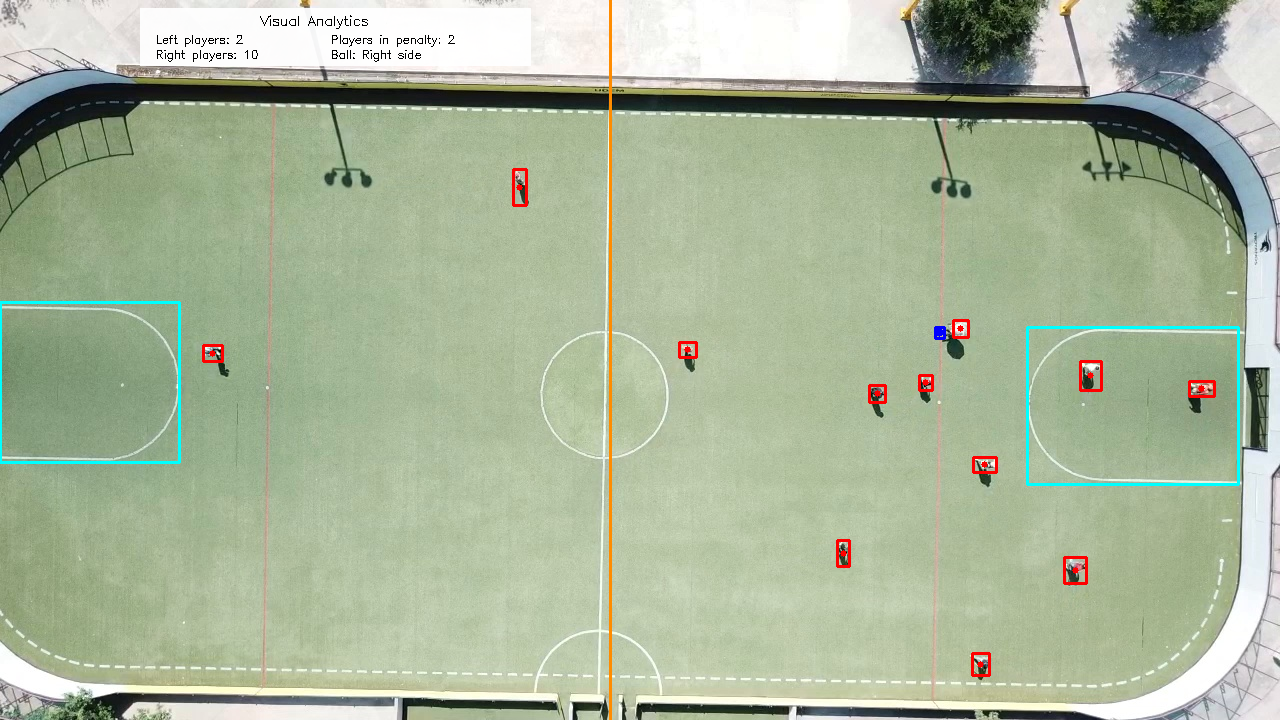

In [ ]:
frame_path = "/content/test_frames/frame_1600.jpg"
frame = cv2.imread(frame_path)

result = get_sliced_prediction(
    frame_path,
    sahi_model,
    slice_height=320,
    slice_width=320,
    overlap_height_ratio=0.25,
    overlap_width_ratio=0.25
)

filtered_predictions = filter_sahi_predictions_all(result)

saved_mc, saved_ac_regions = lock_field_regions(filtered_predictions)

tracked_ball = apply_ball_tracking(filtered_predictions)

final_frame = draw_sahi_with_detected_regions(
    frame,
    filtered_predictions,
    saved_mc=saved_mc,
    saved_ac_regions=saved_ac_regions,
    tracked_ball=tracked_ball
)

cv2_imshow(final_frame)

In [ ]:
# =========================
# Video largo con visual analytics
# =========================

input_video_path = "/content/drive/MyDrive/IA 2/futbol.mp4"

output_video_path = (
    "/content/drive/MyDrive/IA 2/"
    "demo_visual_analytics_500(2)_frames.mp4"
)

cap = cv2.VideoCapture(input_video_path)

# Empezar más adelante en el video
start_frame = 2500
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_video_path,
    fourcc,
    fps,
    (width, height)
)

# Número de frames a procesar
max_frames = 500

frame_count = 0

while cap.isOpened() and frame_count < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    # Guardar frame temporal
    temp_frame_path = "/content/temp_frame.jpg"

    cv2.imwrite(temp_frame_path, frame)

    # =========================
    # SAHI inference
    # =========================

    result = get_sliced_prediction(
        temp_frame_path,
        sahi_model,
        slice_height=320,
        slice_width=320,
        overlap_height_ratio=0.25,
        overlap_width_ratio=0.25
    )

    # =========================
    # Filtrar detecciones
    # =========================

    filtered_predictions = filter_sahi_predictions_all(result)

    # =========================
    # Bloquear MC y AC
    # =========================

    saved_mc, saved_ac_regions = lock_field_regions(
        filtered_predictions
    )

    # =========================
    # Tracking balón
    # =========================

    tracked_ball = apply_ball_tracking(
        filtered_predictions
    )

    # =========================
    # Visual analytics
    # =========================

    output_frame = draw_sahi_with_detected_regions(
        frame,
        filtered_predictions,
        saved_mc=saved_mc,
        saved_ac_regions=saved_ac_regions,
        tracked_ball=tracked_ball
    )

    # Guardar frame
    out.write(output_frame)

    frame_count += 1

    # Mostrar progreso
    if frame_count % 50 == 0:
        print(f"Frames procesados: {frame_count}")

cap.release()
out.release()

print("===================================")
print("Video generado correctamente")
print(output_video_path)
print(f"Frames procesados: {frame_count}")
print("===================================")

Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 

Crash